# 🔋 Otimização do Despacho Energético e Dimensionamento de PV + Bateria

Este notebook implementa um modelo de otimização para analisar e minimizar o custo total de energia de uma instalação com produção fotovoltaica (PV) e sistema de armazenamento em bateria, com base em dados históricos (hindcast) de consumo e produção.

## 🎯 Objetivos

* Determinar o despacho ótimo da energia (rede, PV e bateria) ao longo do tempo
* Minimizar o custo anual total de energia, incluindo:

  * energia comprada à rede (tarifário horário)
  * custo nivelado da produção PV (CAPEX anualizado)
  * custo de utilização da bateria (CAPEX anualizado por throughput)
  * custo de potência contratada (peak shaving)
* Avaliar o dimensionamento ótimo:

  * potência instalada de PV (kWp)
  * capacidade da bateria (kWh)

## ⚙️ Metodologia

O problema é formulado como um modelo de otimização linear (MILP), resolvido com base num horizonte temporal discreto (tipicamente 15 minutos), utilizando dados históricos de carga e produção.

O modelo inclui:

* Balanço energético em cada timestep
* Dinâmica da bateria com eficiência de carga/descarga
* Limites operacionais (potência, capacidade, SOC)
* Restrições tarifárias (ex.: proibição de descarga em vazio)
* Otimização da potência contratada (peak shaving)

## 💰 Modelação Económica

Os custos são modelados de forma consistente com análise de investimento:

* PV: custo nivelado (LCOE) baseado em CAPEX anualizado via CRF
* Bateria: custo por kWh processado (throughput), também anualizado
* Rede: preços horários reais (vazio / fora de vazio)
* Exportação: receita com feed-in tariff (quando aplicável)

## 🔁 Abordagem de Otimização

O dimensionamento ótimo do sistema é obtido através de uma pesquisa paramétrica (grid search), variando:

* tamanho do sistema PV (kWp)
* capacidade da bateria (kWh)

Para cada configuração, o modelo calcula o custo total anual, permitindo identificar a solução economicamente ótima.

## 📊 Outputs

O notebook gera:

* Perfis temporais de operação (SOC, carga/descarga, importação/exportação)
* Indicadores energéticos (autoconsumo, ciclos da bateria)
* Indicadores económicos (custo total, poupança)
* Curvas de custo vs dimensão do sistema

## ⚠️ Nota

Este modelo assume conhecimento perfeito do futuro (hindcast), sendo adequado para análise retrospetiva e dimensionamento, mas não diretamente para controlo em tempo real.

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline  
import locale
locale.setlocale(locale.LC_TIME, "pt_PT") # processar datas em PT
import aosol.series.consumo as series
import aosol.series.producao as seriesprod
import aosol.series.pvgis as pvgis
import aosol.series.precos as precos
import aosol.analise.analise_energia as ae
import aosol.analise.analise_financeira as af
import aosol.analise.analise_precos_energia as ape
import aosol.analise.optimiza_upac as optimiza
from aosol.armazenamento.bateria import bateria

## 1. Produção

In [2]:
# =====================
# Producao
# =====================
ano_producao = 2025 # converter as datas de producao para este ano
# Opcoes API PVGIS
inicio_ano_pvgis = 2005
fim_ano_pvgis = 2023 # PVGIS-SARAH3 na V5.3 (2005-2023)
inclinacao = 30
azimute = 0.0 # azimute = 180 + x; 0 = Sul
perdas = 14 # %
# Lisboa
lat = 38.736
lon = -9.143

In [3]:
producao = pvgis.get_pvgis_hourly(lat, lon, inicio_ano_pvgis, fim_ano_pvgis, surface_tilt=inclinacao, surface_azimuth=azimute, peakpower=1, loss=perdas)
producao = seriesprod.converter_pvgis_multiyear_ts(producao, ano_producao, downscale_para_15min=True)


In [4]:
producao["autoproducao_1kWp"] = producao["autoproducao"] / 0.25 # converter para kW

NEPS Lisboa = 1593 h


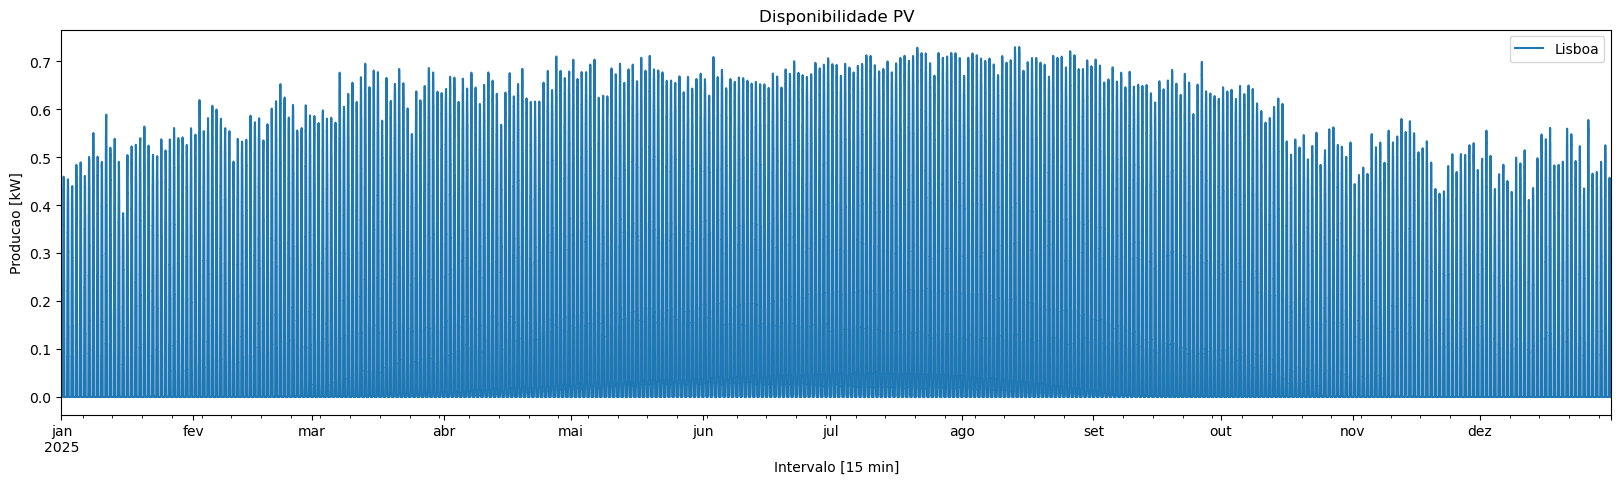

In [5]:
p,ax = plt.subplots(1,1, figsize=(20,5))
producao["autoproducao_1kWp"].plot(ax=ax, label='Lisboa')
plt.legend()
plt.ylabel('Producao [kW]')
plt.xlabel('Intervalo [15 min]')
plt.title('Disponibilidade PV')

print(f"NEPS Lisboa = {producao['autoproducao_1kWp'].sum()*0.25:.0f} h")

Verificar se ha NaNs

In [6]:
# Verificar NaNs em producao['autoproducao_1kWp']
print('Existe NaN? ', producao['autoproducao_1kWp'].isna().any())
print('Total NaNs:', producao['autoproducao_1kWp'].isna().sum())
nan_idx = producao["autoproducao_1kWp"][producao['autoproducao_1kWp'].isna()].index
print('Primeiros índices com NaN:', list(nan_idx)[:20])
# Para inspecionar as linhas com NaN, execute a próxima linha (ela retorna as primeiras ocorrências)
producao['autoproducao_1kWp'][nan_idx].head()

Existe NaN?  False
Total NaNs: 0
Primeiros índices com NaN: []


Series([], Freq: 15T, Name: autoproducao_1kWp, dtype: float64)

## 2. Consumo

In [7]:
# =====================
# Consumo
# =====================
ano_consumo = 2025
perfil = 'BTN C' # ver na document
consumo_anual = 3600 # 300 kWh/mes
fich_perfil_eredes = r"./consumo/perfis_eredes/Perfil_Consumo_Injeção_E-REDES_2025.csv"

In [8]:
perfil_eredes = series.leitura_perfis_eredes(fich_perfil_eredes, perfil)
consumo = series.ajustar_perfil_eredes_a_consumo_anual(perfil_eredes, consumo_anual, 'BTN C', 'consumo', resample_horario=False)

In [9]:
consumo["consumo_kW"] = consumo["consumo"] / 0.25 # converter para kW

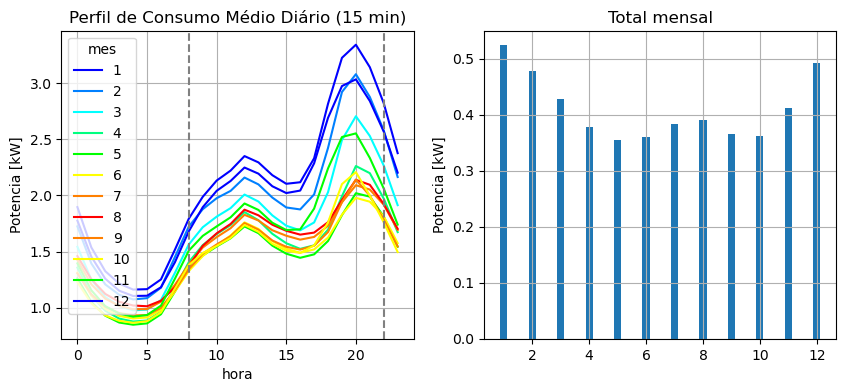

In [10]:
ae.plot_perfil_12x24_e_mensal(consumo, 'consumo_kW', quartohorario=True, agregacao_mensal='mean', ylabel="Potencia [kW]", titulo="Perfil de Consumo Médio Diário (15 min)")

In [ ]:
energia12x24 = ae.calcula_12x24(consumo, "consumo", quartohorario=True)
#energia12x24

mes,1,2,3,4,5,6,7,8,9,10,11,12
hora,,,,,,,,,,,,
0,0.474048,0.431157,0.385681,0.339271,0.315548,0.328167,0.356138,0.364961,0.326490,0.307063,0.348800,0.443923
1,0.384307,0.348566,0.313012,0.277629,0.262673,0.277123,0.302153,0.313325,0.279709,0.259707,0.288834,0.363652
2,0.331351,0.302042,0.274018,0.243406,0.232294,0.247442,0.270171,0.280701,0.252063,0.232813,0.253548,0.314611
3,0.303804,0.278771,0.253318,0.225806,0.217019,0.231788,0.254058,0.263239,0.238165,0.220853,0.236828,0.287888
4,0.290399,0.268459,0.244219,0.219295,0.212137,0.225990,0.246583,0.254946,0.232866,0.216410,0.230082,0.276156
5,0.291338,0.271289,0.245861,0.221442,0.215136,0.228304,0.246871,0.253257,0.233534,0.220015,0.233694,0.276674
6,0.313022,0.294660,0.266974,0.240970,0.235491,0.245030,0.263512,0.265554,0.249408,0.239498,0.254613,0.295565
7,0.379028,0.362662,0.327449,0.293404,0.285805,0.285798,0.300740,0.295348,0.289124,0.292570,0.314466,0.351072
8,0.448330,0.430839,0.390914,0.351583,0.337539,0.331646,0.346432,0.342592,0.335866,0.345022,0.377109,0.420161


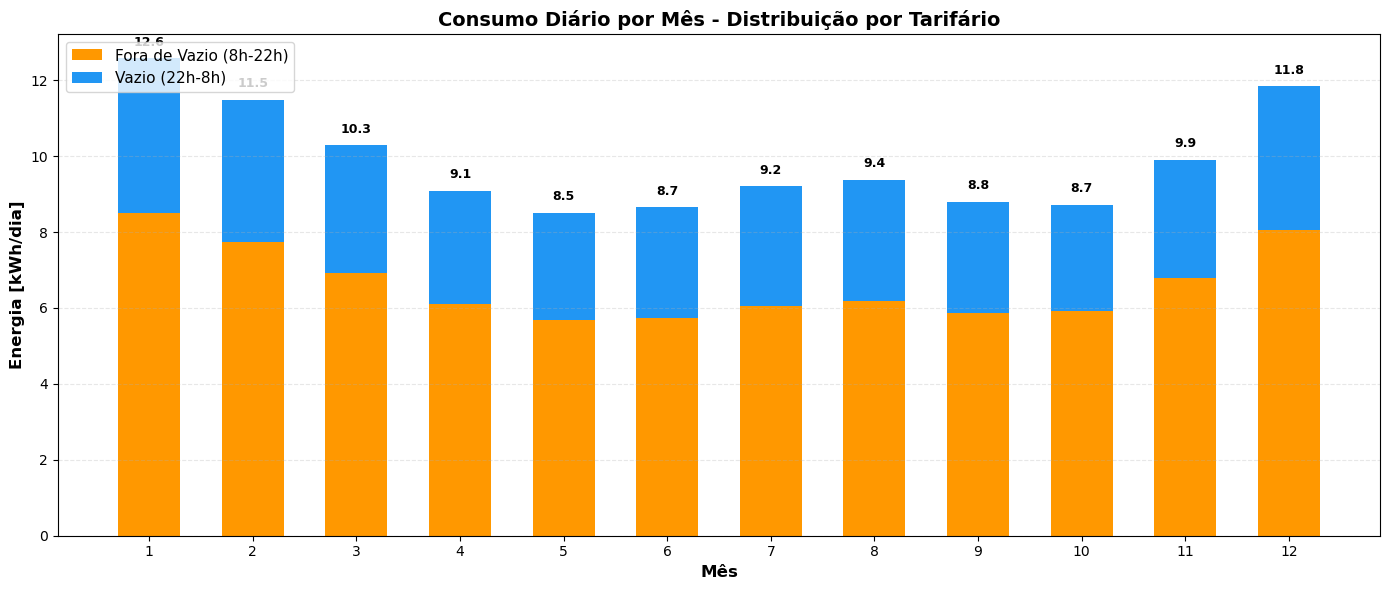


Detalhes do Consumo por Mês:
 Mês  Total (kWh/dia)  Fora Vazio (kWh/dia)  Vazio (kWh/dia)  % Fora Vazio   % Vazio
   1        12.578129              8.511128         4.067001     67.666093 32.333907
   2        11.478178              7.734678         3.743501     67.385934 32.614066
   3        10.279211              6.923619         3.355592     67.355545 32.644455
   4         9.085149              6.112440         2.972709     67.279471 32.720529
   5         8.502718              5.687714         2.815004     66.892892 33.107108
   6         8.655244              5.738140         2.917104     66.296690 33.703310
   7         9.204303              6.061369         3.142935     65.853639 34.146361
   8         9.380430              6.182317         3.198113     65.906540 34.093460
   9         8.794044              5.860174         2.933870     66.637987 33.362013
  10         8.712928              5.909939         2.802988     67.829548 32.170452
  11         9.901164              

In [ ]:
# Calcular consumo diário por mês e percentagem fora de vazio (8h-22h)
meses = energia12x24.columns  # Obter nomes dos meses a partir do índice
consumo_diario = energia12x24.sum(axis=0)  # Sum of all hours

# Identificar horas fora de vazio (8-22) e vazio (outras)
horas_fora_vazio = list(range(8, 22))  # 8h a 22h
horas_vazio = [h for h in range(24) if h not in horas_fora_vazio]

consumo_fora_vazio = energia12x24.iloc[horas_fora_vazio, :].sum(axis=0)
consumo_vazio = energia12x24.iloc[horas_vazio, :].sum(axis=0)

# Criar figura
fig, ax = plt.subplots(figsize=(14, 6))

# Criar barras stacked
x = meses #np.arange(len(consumo_diario))
width = 0.6

bars1 = ax.bar(x, consumo_fora_vazio, width, label='Fora de Vazio (8h-22h)', color='#FF9800')
bars2 = ax.bar(x, consumo_vazio, width, bottom=consumo_fora_vazio, label='Vazio (22h-8h)', color='#2196F3')

# Adicionar labels com valor total em cada barra
for i, (total, fv, vz) in enumerate(zip(consumo_diario, consumo_fora_vazio, consumo_vazio)):
    ax.text(meses[i], total + max(consumo_diario)*0.02, f'{total:.1f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=9)

# Configuração dos eixos e labels
ax.set_xlabel('Mês', fontsize=12, fontweight='bold')
ax.set_ylabel('Energia [kWh/dia]', fontsize=12, fontweight='bold')
ax.set_title('Consumo Diário por Mês - Distribuição por Tarifário', fontsize=14, fontweight='bold')
ax.set_xticks(x)
#ax.set_xticklabels([f'{meses.iloc[i][:3]}\n({energia12x24.index[i]})' for i in range(len(meses))], fontsize=10)
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Mostrar tabela com os valores
print("\nDetalhes do Consumo por Mês:")
print("="*70)
df_resumo = pd.DataFrame({
    'Mês': meses,#[f"{meses.iloc[i]} ({energia12x24.index[i].month})" for i in range(len(meses))],
    'Total (kWh/dia)': consumo_diario.values,
    'Fora Vazio (kWh/dia)': consumo_fora_vazio.values,
    'Vazio (kWh/dia)': consumo_vazio.values,
    '% Fora Vazio': (consumo_fora_vazio / consumo_diario * 100).values,
    '% Vazio': (consumo_vazio / consumo_diario * 100).values
})
print(df_resumo.to_string(index=False))

## 3. Modelo

In [ ]:
def corre_otimizacao(df, params, r_pv, r_bat):
    results = []

    # consumo anual
    consumo_anual_kwh = params["consumo_anual"]
    consumo_anual_mwh = consumo_anual_kwh / 1000

    # -----------------------------------
    # PV
    # -----------------------------------
    pv_kwp = (r_pv * consumo_anual_kwh) / params["Y"]
    df["autoproducao_kW"] = (pv_kwp * df["autoproducao_1kWp"])
    params["kWp"] = pv_kwp
    params["capex_pv"] = (pv_kwp * params["pv_por_kW"])
    #params["pv_annual_kwh"] = (r_pv * E_load_annual_kwh)

            #for r_bat in r_bats:
    # -----------------------------------
    # Bateria
    # -----------------------------------
    capacidade_bat_kwh = (r_bat * consumo_anual_mwh)

    params["capacidade_bat"] = capacidade_bat_kwh
    params["capex_bat"] = (capacidade_bat_kwh * params["bat_por_kWh"])
    # throughput anual aproximado
    params["ciclos_bat_ano"] = 250

    #print(params)
    # correr otimização
    res, lcoe, pot_max_rede = optimiza.optimiza_sistema(df, params)
    return lcoe, pot_max_rede, res

    # results.append({
    #     "pv_price_kwp": preco_kwp,
    #     "r_pv": r_pv,
    #     "r_bat": r_bat,
    #     "pv_kwp": pv_kwp,
    #     "bat_capacity_kwh": capacidade_bat_kwh,
    #     "cost": cost,
    #     "grid_peak": peak,
    #     "iac": indicadores["iac"],
    #     "ias": indicadores["ias"]
    # })

    # res_df = pd.DataFrame(results)

## 4. Optimização

### 4.1 Optimização onde bateria é incentivado carregar da rede (Cdeg < spread tarifário).

* Cdeg = 0.03
* spread tarifário = 0.069

In [13]:
# Precos Gold energy (spread tarifario = 0.07)
preco_vazio = 0.0894
preco_fora_vazio = 0.1584
preco_pot_contratada = 0.3054

# Parametros
params = {
    "dt": 0.25, # intervalo de tempo em horas (15 minutos)
    "consumo_anual": consumo_anual, # consumo anual de energia [kWh/ano]

    # economia
    "taxa_actualizacao": 5, # taxa de desconto em percentagem (por exemplo, 5 para 5%)
    "preco_venda_rede": 0.00, # preço de venda da energia para a rede [€/kWh]
    "simples_kWh": None,
    "vazio_kWh": 0.0894,  # Gold energy 10/02
    "fora_vazio_kWh": 0.1584, # Gold energy 10/02
    # Tarifarios indexados
    #"omie": precos_omie,
    #"tar_simples": 0.06,
    #"tar_vazio": 0.02,
    #"tar_fora_vazio": 0.08,
    #"tarifario_indexado": ape.TarifariosIndexados.CoopernicoBase,

    # PV
    "tempo_vida": 20, # vida útil do sistema fotovoltaico em anos
    "pv_por_kW": 1000, # custo de investimento do sistema fotovoltaico por kW instalado [€/kWp]
    "perc_custo_manutencao": 0, # percentual do capex do PV para custos de manutenção anual (em percentagem, por exemplo, 1 para 1%)
    "opex_pv": 0, # custo operacional anual do sistema fotovoltaico por kW instalado [€/kWp/ano]
    "Y": (producao["autoproducao_1kWp"] * 0.25).sum(),# producao esperada do sistema fotovoltaico por kW instalado [kWh/kWp/ano]
    "ef_inv": 0.98, # eficiência do inversor

    # Bateria
    #"pv_annual_kwh": None, # produção anual de energia [kWh/ano]
    "Cdeg": 0.03, # custo marginal da bateria (custo atribuido de operação).
    "tempo_vida_bat": 20, # vida útil da bateria em anos
    "bat_por_kWh": 400, # custo de investimento da bateria por kWh instalado [€/kWh]
    "DoD": 0.9, # profundidade de descarga da bateria (em decimal, por exemplo, 0.8 para 80%)
    "ef_carga_bat": 0.95, # eficiência de carga da bateria (em decimal, por exemplo, 0.9 para 90%)
    "ef_descarga_bat": 0.95, # eficiência de descarga da bateria
    "Pmax": 5.0, # potência máxima de carga/descarga da bateria [kW]
    "permite_descarga_vazio": False, # booleano indicando se é permitido descarregar a bateria durante períodos vazios
    "reinvestir_bat": False, # considerar 2a bateria apos tempo de vida
    
    # rede
    "potencia_max_rede": 3.45, # potência máxima contratada da rede [kW]
    "custo_pot_contratada": preco_pot_contratada # custo potência contratada por dia [€/dia]
}

# Series Temporais
df = pd.DataFrame({
    "autoproducao_1kWp": producao["autoproducao_1kWp"],
    "consumo_kW": consumo["consumo_kW"]
})  

df["autoproducao_1kWp"] = df["autoproducao_1kWp"].fillna(0)

ape.identifica_periodo_tarifario_bihorario(df)
df["e_vazio"] = (df["periodo tarifario"] == "vazio")
df["preco"] = df["periodo tarifario"].apply(lambda x: preco_vazio if x == "vazio" else preco_fora_vazio)
df.drop(columns=["bins"], inplace=True)

In [14]:
idx = df.index[df.isna().any(axis=1)]
print("Nº linhas com NaN:", len(idx))
print(idx[:20])
df[df.isna().any(axis=1)].head()

Nº linhas com NaN: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='15T')


,autoproducao_1kWp,consumo_kW,periodo tarifario,e_vazio,preco


In [15]:
opt_resultados = pd.DataFrame()

In [16]:
#r_pv = 0.9
#r_bat = 0.7
r_pvs = np.linspace(0.5, 2.5, 8)
r_bats = np.linspace(0.5, 2.5, 8)
for ipv in range(len(r_pvs)):
    r_pv = r_pvs[ipv]
    for ibat in range(len(r_bats)):
        r_bat = r_bats[ibat]
        print(f"Otimizando para r_pv={r_pv:.2f} e r_bat={r_bat:.2f}...")
        lcoe, pot_max_rede, res = corre_otimizacao(df, params, r_pv, r_bat)
    
        # Indicadores auto consumo
        res.index = df.index
        # converter para energia
        res = res * params["dt"] # converter de potencia para energia (intervalo de 15 minutos = 0.25 horas)

        pv_kwp = (r_pv * params["consumo_anual"]) / params["Y"]
        bat = bateria(params["capacidade_bat"], 1-params["DoD"], 1.0, params["ef_carga_bat"]*params["ef_descarga_bat"], params["Pmax"])
        indicadores = ae.calcula_indicadores_autoconsumo(res, pv_kwp, params["ef_inv"], bat, subtrai_descarga_origem_rede=True)

        coe, coa, custo_medio_compra_rede = af.custo_energia_prosumidor(indicadores, res["consumo_rede"], ape.TarifarioPeriodoHorario.Bihorario, ape.TipoTarifario.Fixo, params)
        #print(f"LCOE: {coe:.4f} €/kWh")
        #print(f"LCOS: {coa:.4f} €/kWh")
        #print(f"Custo médio compra rede: {custo_medio_compra_rede:.4f} €/kWh")

        # transforma indicadores em DataFrame de 1 linha
        ind_df = indicadores.to_frame()
        # adiciona colunas de parâmetros e custos
        ind_df["r_pv"] = r_pv
        ind_df["r_bat"] = r_bat
        ind_df["COE"] = coe        # custo de energia equivalente
        ind_df["COA"] = coa        # custo anualizado do ativo (ou outro nome que uses)
        ind_df["custo_medio_compra_rede"] = custo_medio_compra_rede
        # concatena ao frame de resultados
        opt_resultados = pd.concat([opt_resultados, ind_df], ignore_index=False)

Otimizando para r_pv=0.50 e r_bat=0.50...
Otimizando para r_pv=0.50 e r_bat=0.79...
Otimizando para r_pv=0.50 e r_bat=1.07...
Otimizando para r_pv=0.50 e r_bat=1.36...
Otimizando para r_pv=0.50 e r_bat=1.64...
Otimizando para r_pv=0.50 e r_bat=1.93...
Otimizando para r_pv=0.50 e r_bat=2.21...
Otimizando para r_pv=0.50 e r_bat=2.50...
Otimizando para r_pv=0.79 e r_bat=0.50...
Otimizando para r_pv=0.79 e r_bat=0.79...
Otimizando para r_pv=0.79 e r_bat=1.07...
Otimizando para r_pv=0.79 e r_bat=1.36...
Otimizando para r_pv=0.79 e r_bat=1.64...
Otimizando para r_pv=0.79 e r_bat=1.93...
Otimizando para r_pv=0.79 e r_bat=2.21...
Otimizando para r_pv=0.79 e r_bat=2.50...
Otimizando para r_pv=1.07 e r_bat=0.50...
Otimizando para r_pv=1.07 e r_bat=0.79...
Otimizando para r_pv=1.07 e r_bat=1.07...
Otimizando para r_pv=1.07 e r_bat=1.36...
Otimizando para r_pv=1.07 e r_bat=1.64...
Otimizando para r_pv=1.07 e r_bat=1.93...
Otimizando para r_pv=1.07 e r_bat=2.21...
Otimizando para r_pv=1.07 e r_bat=

In [17]:
opt_resultados.to_excel("15min_milp_carrega_bateria_rede.xlsx", index=False)

In [18]:
opt_resultados.head()

,Potencia instalada [kW],IAS: Contributo PV [%],IAC: Indice Auto consumo [%],IER: Producao PV desperdicada [%],Energia consumida [kWh],Energia Autoproduzida [kWh],Energia Autoconsumida [kWh],Energia consumida rede [kWh],Energia injectada rede [kWh],Perdas inversor [kWh],...,Energia fornecida bateria [kWh],Perdas bateria [kWh],Ciclos da bateria,Energia rede para carga bateria [kWh],residuo,r_pv,r_bat,COE,COA,custo_medio_compra_rede
label,,,,,,,,,,,,,,,,,,,,,
indicadores,1.130164,47.407063,94.814498,5.185502,3600.014155,1800.0,1706.660970,1892.590911,29.747252,34.743410,...,588.591048,62.829504,326.995027,257.592436,-34.743410,0.5,0.500000,0.097600,0.098158,0.107208
indicadores,1.130164,47.422837,94.846047,5.153953,3600.014155,1800.0,1707.228838,1890.746597,0.000000,34.185351,...,850.880884,90.732442,300.816474,518.037958,-34.185351,0.5,0.785714,0.101698,0.106700,0.097653
indicadores,1.130164,47.109735,94.219841,5.780159,3600.014155,1800.0,1695.957141,1902.578064,0.000000,33.948722,...,964.406586,102.563909,250.031337,643.395127,-33.948722,0.5,1.071429,0.108986,0.128372,0.093485
indicadores,1.130164,47.060486,94.121342,5.878658,3600.014155,1800.0,1694.184149,1903.729587,0.000000,33.925691,...,979.074346,103.715432,200.395334,659.214410,-33.925691,0.5,1.357143,0.117904,0.160169,0.092951
indicadores,1.130164,47.071495,94.143360,5.856640,3600.014155,1800.0,1694.580472,1903.501794,0.000000,33.930247,...,980.974591,103.487639,165.865269,660.886862,-33.930247,0.5,1.642857,0.127033,0.193513,0.092882


In [19]:
import matplotlib
import matplotlib.cm as cm
def plot_estudo_com_bateria(resultados, coluna_lcoe, coluna_ias, ax, titulo):
    """ Plot dos resultados do estudo com bateria.

    Parameters
    ----------
    resultados : pd.DataFrame
        Dataframe com os resultados para os vários r_pv e r_bat.
    coluna_lcoe : str
        Nome da coluna no dataframe que contém os valores de LCOE a plotar.
    coluna_ias : str
        Nome da coluna no dataframe que contém os valores de IAS a plotar. Se None, não plota as curvas de IAS.
    ax : axis
        Matplotlib axis onde fazer a plot.
    titulo : str
        Titulo da plot.
    """
    r_pv = np.array(resultados["r_pv"].unique())
    r_bat = np.array(resultados["r_bat"].unique())
    PV, BAT = np.meshgrid(r_pv, r_bat)
    if coluna_ias is not None:
        IAS = resultados[coluna_ias].values.reshape(len(r_pv), len(r_bat))

    LCOE = resultados[coluna_lcoe].values.reshape(len(r_pv), len(r_bat))
    
    matplotlib.rcParams['xtick.direction'] = 'out'
    matplotlib.rcParams['ytick.direction'] = 'out'

    levels = np.arange(0.10,0.30,0.01)
    levels_ias = np.arange(30, 100, 5)

    if coluna_ias is not None:
        CS1 = ax.contour(PV, BAT, IAS, colors='black', linewidths=1., linestyles='--', levels=levels_ias)
    CS = ax.contour(PV, BAT, LCOE, colors='black', linewidths=1.,levels=levels)
    CS2 = ax.contourf(PV, BAT, LCOE, cmap=cm.Purples, alpha=0.5,levels=levels)
    ax.grid()
    ax.clabel(CS, inline=1, fontsize=10)
    if coluna_ias is not None:
        ax.clabel(CS1, inline=1, fontsize=10)
    ax.set_title(titulo)
    ax.set_xlabel('PV [kWh/kWh]')
    ax.set_ylabel('BATERIA [kWh/MWh]')

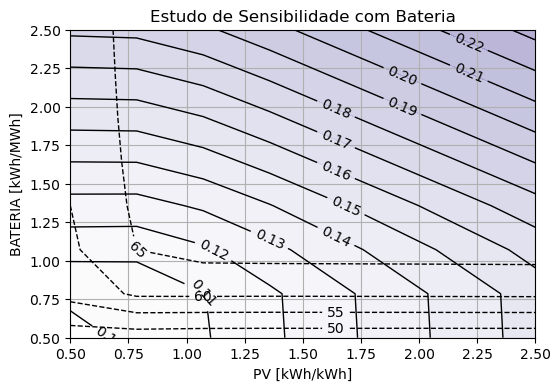

In [22]:
#fig, ax = plt.subplots(1, 1, figsize=(12, 5), sharey=True)
ax = plt.figure(figsize=(6, 4)).gca()
plot_estudo_com_bateria(opt_resultados, "COE", "IAS: Contributo PV [%]", ax, "Estudo de Sensibilidade com Bateria")

Vericar sistema com rpv > rbat

* r_pv = 1.0
* r_bat = 0.75

In [23]:
r_pv = 1.0
r_bat = 0.75
lcoe, pot_max_rede, res = corre_otimizacao(df, params, r_bat, r_bat)

In [24]:

# Indicadores auto consumo
res.index = df.index
# converter para energia 
cols = ["consumo","consumo_rede","injeccao_rede","autoconsumo","autoproducao","carga_bateria","descarga_bateria"]
res[cols] = res[cols].mul(params["dt"], axis=0) # converter de potencia para energia (intervalo de 15 minutos = 0.25 horas)

pv_kwp = (r_pv * params["consumo_anual"]) / params["Y"]
bat = bateria(params["capacidade_bat"], 1-params["DoD"], 1.0, params["ef_carga_bat"]*params["ef_descarga_bat"], params["Pmax"])
indicadores = ae.calcula_indicadores_autoconsumo(res, pv_kwp, params["ef_inv"], bat, subtrai_descarga_origem_rede=True)

coe, coa, custo_medio_compra_rede = af.custo_energia_prosumidor(indicadores, res["consumo_rede"], ape.TarifarioPeriodoHorario.Bihorario, ape.TipoTarifario.Fixo, params)
print(f"LCOE: {coe:.4f} €/kWh")
print(f"LCOS: {coa:.4f} €/kWh")
print(f"Custo médio compra rede: {custo_medio_compra_rede:.4f} €/kWh")
indicadores.print_html()

LCOE: 0.1136 €/kWh
LCOS: 0.1071 €/kWh
Custo médio compra rede: 0.0971 €/kWh


label,indicadores
Potencia instalada [kW],2.3
IAS: Contributo PV [%],59.7
IAC: Indice Auto consumo [%],79.6
IER: Producao PV desperdicada [%],20.4
Energia consumida [kWh],3600.0
Energia Autoproduzida [kWh],2700.0
Energia Autoconsumida [kWh],2149.8
Energia consumida rede [kWh],1450.0
Energia injectada rede [kWh],463.6
Perdas inversor [kWh],52.3


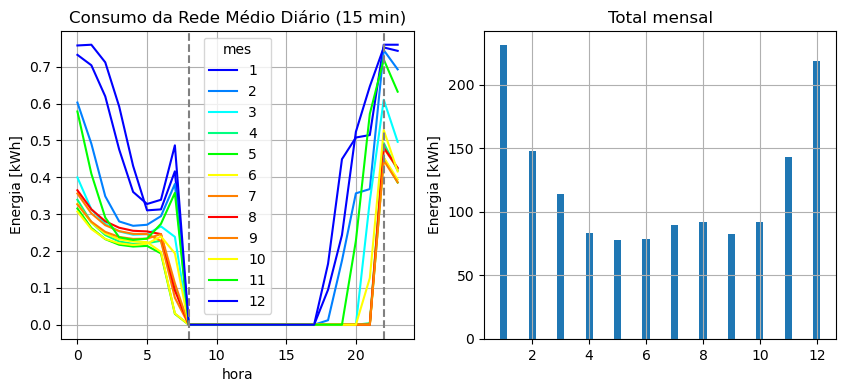

In [29]:
#consumo_rede_12x24 = ae.calcula_12x24(res, "consumo_rede", quartohorario=True)
ae.plot_perfil_12x24_e_mensal(res, 'consumo_rede', quartohorario=True, agregacao_mensal='sum', ylabel="Energia [kWh]", titulo="Consumo da Rede Médio Diário (15 min)")

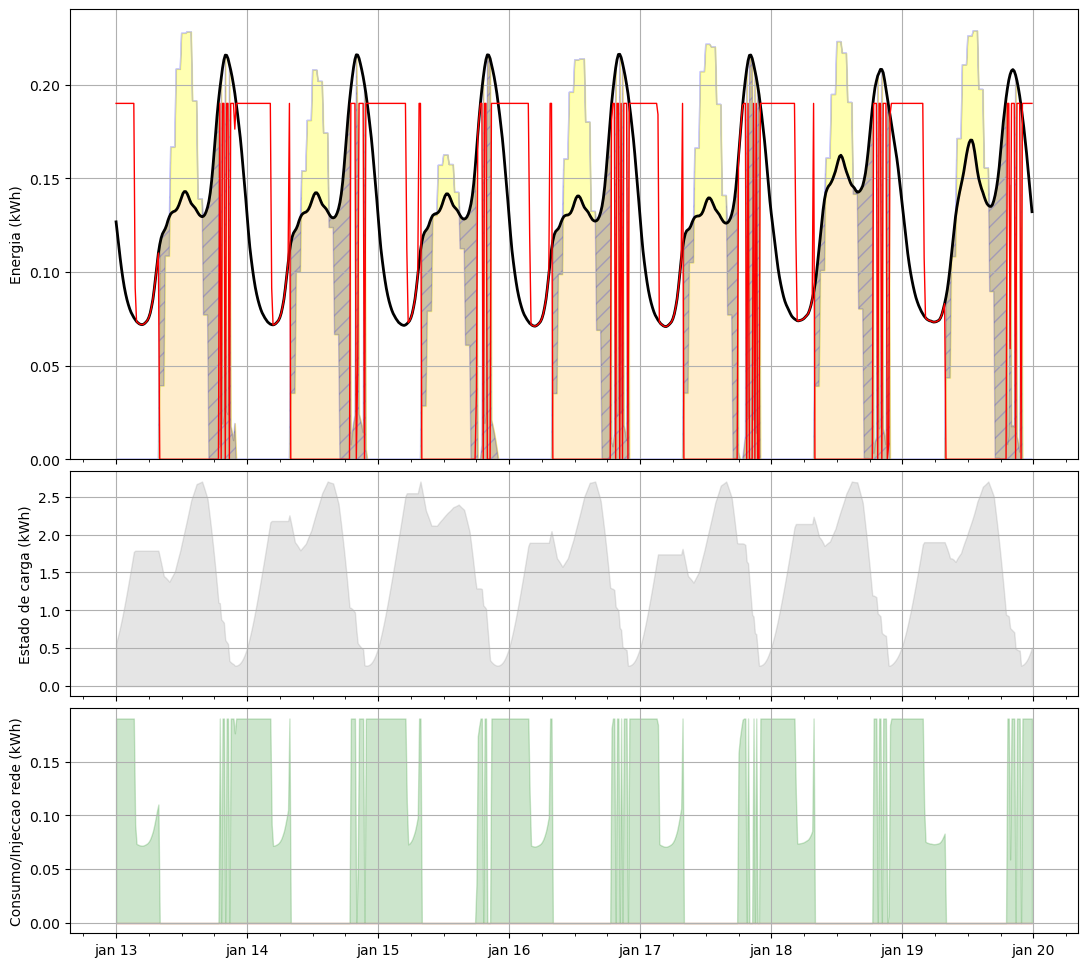

In [32]:
ae.plot_despacho_energia(res, semana=3)

### 4.2 Optimização onde bateria não carrega da rede

Cdeg = 0.08

In [45]:
params["Cdeg"] = 0.08
opt_resultados2 = pd.DataFrame()

In [46]:
r_pv = 0.9
r_bat = 0.7
lcoe, pot_max_rede, res2 = corre_otimizacao(df, params, r_pv, r_bat)
    
# Indicadores auto consumo
res2.index = df.index
# converter para energia
res2 = res2 * params["dt"] # converter de potencia para energia (intervalo de 15 minutos = 0.25 horas)

pv_kwp = (r_pv * params["consumo_anual"]) / params["Y"]
bat = bateria(params["capacidade_bat"], 1-params["DoD"], 1.0, params["ef_carga_bat"]*params["ef_descarga_bat"], params["Pmax"])
indicadores2 = ae.calcula_indicadores_autoconsumo(res2, pv_kwp, params["ef_inv"], bat, subtrai_descarga_origem_rede=True)

coe, coa, custo_medio_compra_rede = af.custo_energia_prosumidor(indicadores2, res2["consumo_rede"], ape.TarifarioPeriodoHorario.Bihorario, ape.TipoTarifario.Fixo, params)
print(f"LCOE: {coe:.4f} €/kWh")
print(f"LCOS: {coa:.4f} €/kWh")
print(f"Custo médio compra rede: {custo_medio_compra_rede:.4f} €/kWh")

# transforma indicadores em DataFrame de 1 linha
ind_df = indicadores2.to_frame()
# adiciona colunas de parâmetros e custos
ind_df["r_pv"] = r_pv
ind_df["r_bat"] = r_bat
ind_df["COE"] = coe        # custo de energia equivalente
ind_df["COA"] = coa        # custo anualizado do ativo (ou outro nome que uses)
ind_df["custo_medio_compra_rede"] = custo_medio_compra_rede
# concatena ao frame de resultados
opt_resultados2 = pd.concat([opt_resultados2, ind_df], ignore_index=False)

LCOE: 0.1351 €/kWh
LCOS: 0.3203 €/kWh
Custo médio compra rede: 0.1192 €/kWh


In [47]:
indicadores2.print_html()

label,indicadores
Potencia instalada [kW],2.0
IAS: Contributo PV [%],43.5
IAC: Indice Auto consumo [%],98.4
IER: Producao PV desperdicada [%],1.6
Energia consumida [kWh],3600.0
Energia Autoproduzida [kWh],1592.7
Energia Autoconsumida [kWh],1566.7
Energia consumida rede [kWh],2033.3
Energia injectada rede [kWh],0.0
Perdas inversor [kWh],31.3
